In [1]:
"""

1. 加载数据
2. 建立模型
3. 训练模型
4. 预测和评估模型
5. 保存和加载模型
6. 整合内容

"""
import torch
from torch import nn # nn 包含了 Pytorch 构建神经网络的所有模块
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用于正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用于正常显示负号

torch.__version__

'2.9.0+cu126'

# 1. 数据准备和加载

在机器学习中，数据可以是任何东西

* Excel表格
* 任何类型的图片
* 视频
* 音频
* DNA
* 文本

机器学习是由两部分组成的过程：
1. 将数据转换成数值表示
2. 构建模型来学习其中模式

In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X =  torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

## 划分数据集

In [4]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [5]:
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

In [6]:
def plot_predictions(
        train_data = X_train,
        train_labels = y_train,
        test_data = X_test,
        test_labels = y_test,
        predictions = None

):
    """
    绘制训练集和测试集的数据

    :param train_data:
    :param train_labels:
    :param test_data:
    :param test_labels:
    :param predictions:
    :return:
    """
    plt.figure(figsize=(10,7))

    # 绘制训练集数据用蓝色表示
    plt.scatter(train_data, train_labels, c="b", s=4, label="训练集数据")


    # 绘制训练集数据用绿色表示
    plt.scatter(test_data, test_labels, c="g", s=4, label="测试集数据")

    # 是否有预测数据
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="预测结果")

    plt.legend(prop={"size":14})



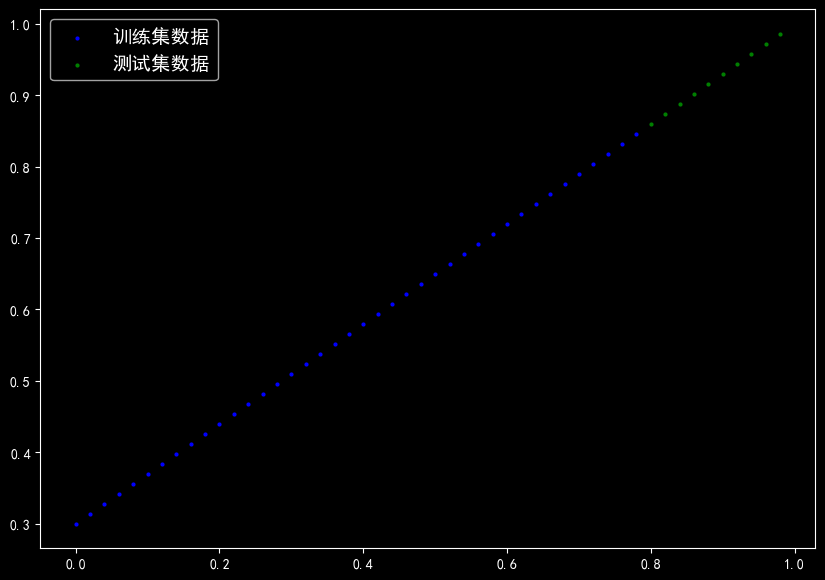

In [7]:
plot_predictions()

## 2. 建立模型

In [8]:
# 创建线性回归分类模型
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                                requires_grad=True,
                                                dtype=torch.float))

        self.bias = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
        # 前向传播
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias